# 03 – Análisis del mapa de Hénon

El mapa de Hénon es un sistema dinámico bidimensional clásico definido por

$$
\begin{cases}
x_{n+1} = 1 - a x_n^2 + y_n,\\\\
y_{n+1} = b x_n,
\end{cases}
$$

donde $a$ y $b$ son parámetros reales. Para los valores "clásicos"

$$
a = 1.4, \qquad b = 0.3,
$$

el sistema presenta un atractor extraño muy conocido y un comportamiento caótico.

En este notebook se estudiarán:

1. La evolución temporal de $(x_n, y_n)$ y el retrato de fase.
2. El atractor de Hénon para los parámetros clásicos.
3. Un diagrama tipo "bifurcación" al variar el parámetro $a$ (con $b$ fijo).
4. El exponente de Lyapunov máximo $\lambda_1(a)$.
5. El efecto del número de iteraciones transitorias al aproximar el atractor.
6. La justificación empírica del umbral de binarización en el generador de bits.
7. Las limitaciones numéricas debidas a la aritmética en coma flotante y sus implicaciones sobre el tamaño efectivo del espacio de claves.
8. Una breve conclusión con las ideas principales del análisis.

Además, en el apéndice se analiza:

- **Apéndice A** – Sensibilidad del mapa de Hénon frente a pequeñas variaciones del parámetro $a$.


## 0. Preparación del entorno

En esta sección se configura el entorno de trabajo:

- Se añade al `sys.path` la carpeta raíz del proyecto para poder importar los módulos de `analysis` y `utils`.
- Se importan las funciones auxiliares definidas en `analysis.henon_analysis`, análogas a las usadas en los mapas logístico y *tent*:

  - `plot_time_series_henon(...)` – dibuja la serie temporal de $x_n$.
  - `plot_attractor_henon(...)` – visualiza el atractor de Hénon en el plano $(x_n, y_n)$.
  - `plot_bifurcation_henon_a(...)` – genera un diagrama tipo bifurcación al variar el parámetro $a$ (con $b$ fijo).
  - `plot_lyapunov_vs_a_henon(...)` – calcula y representa el exponente de Lyapunov máximo $\lambda_1(a)$.
  - `explore_transient_effect_henon(...)` – estudia el efecto del número de iteraciones transitorias en estadísticas simples de la órbita.
  - `threshold_effect_henon(...)` – calcula, para distintos umbrales de binarización $\theta$, la proporción de unos $p(1)$ de la secuencia resultante.
  - `plot_threshold_effect_henon(...)` – representa gráficamente $p(1)$ en función del umbral $\theta$.
  - `detect_cycle_henon(...)` – busca de forma aproximada ciclos periódicos en una órbita larga del mapa de Hénon.
  - `divergence_two_orbits_henon(...)` – calcula la divergencia de dos órbitas con condiciones iniciales muy próximas.
  - `plot_divergence_two_orbits_henon(...)` – representa gráficamente esa divergencia, normalmente en escala semilogarítmica.

- **Función para el apéndice:**
  - `plot_divergence_two_params_henon(...)` – analiza la sensibilidad del sistema
  frente a pequeñas variaciones del parámetro $a$ comparando dos órbitas con
  la misma condición inicial.

- Además, se importan utilidades numéricas genéricas desde `utils.numerics_utils`, independientes del mapa concreto:

  - `float_spacing_around_05(...)` – estima la separación entre números de doble precisión alrededor de $x = 0.5$.
  - `interval_capacity(...)` – calcula el número aproximado de valores `float64` distintos en un intervalo de longitud $L$.
  - `bits_from_interval(...)` – estima los bits de entropía aportados por una variable real restringida a un intervalo de longitud $L$.

En las secciones siguientes utilizaremos estas funciones para explorar cuantitativamente el comportamiento del mapa de Hénon y para estimar el tamaño efectivo del espacio de claves cuando se emplean parámetros y condiciones iniciales en doble precisión.


In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Añadimos la carpeta raíz del proyecto (una arriba de notebooks)
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Importamos las funciones específicas del mapa de Hénon
from analysis.henon_analysis import (
    plot_time_series_henon,
    plot_attractor_henon,
    plot_bifurcation_henon_a,
    plot_lyapunov_vs_a_henon,
    explore_transient_effect_henon,
    threshold_effect_henon,
    plot_threshold_effect_henon,
    detect_cycle_henon,
    divergence_two_orbits_henon,
    plot_divergence_two_orbits_henon,
    # Función para el apéndice
    plot_divergence_two_params_henon,
)

# Utilidades numéricas genéricas
from utils.numerics_utils import (
    float_spacing_around_05,
    interval_capacity,
    bits_from_interval,
)


## 1. Órbita y serie temporal para parámetros clásicos

Recordamos el mapa:

$$
\begin{cases}
x_{n+1} = 1 - a x_n^2 + y_n, \\
y_{n+1} = b x_n.
\end{cases}
$$

En esta sección tomamos los parámetros clásicos

$$
a = 1.4, \qquad b = 0.3
$$

y una condición inicial sencilla, por ejemplo $(x_0, y_0) = (0, 0)$.

Primero representamos la **serie temporal de $x_n$**, que ya muestra 
una dinámica irregular, y después estudiaremos el atractor en el plano 
$(x_n, y_n)$.


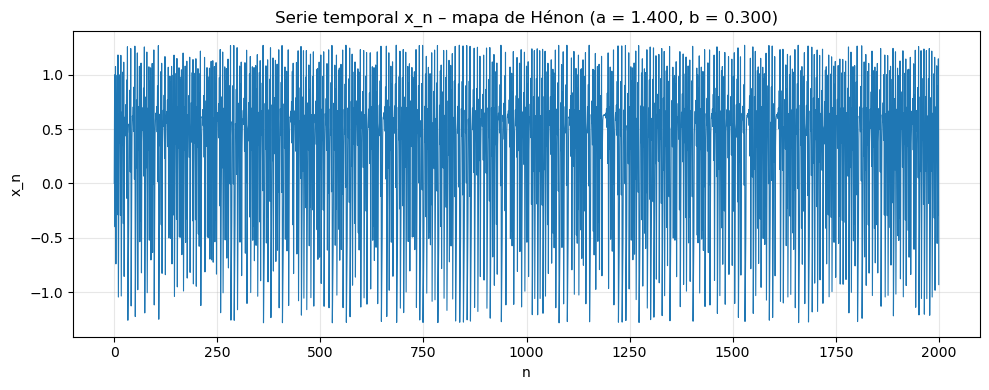

In [2]:
a = 1.4
b = 0.3
x0, y0 = 0.0, 0.0

plot_time_series_henon(x0=x0, y0=y0, a=a, b=b, n_iters=2000)


#### Interpretación de la serie temporal $x_n$ en el mapa de Hénon

La gráfica anterior muestra la evolución temporal de la coordenada $x_n$ del
mapa de Hénon para un par fijo de parámetros $(a,b)$ y una condición inicial
$(x_0, y_0)$.

Se observa que:

- La señal no converge a un punto fijo ni a un ciclo de periodo corto:
  los valores de $x_n$ continúan oscilando a lo largo de todo el intervalo
  de tiempo representado.
- El comportamiento es aparentemente irregular, sin patrones periódicos
  claros a simple vista, lo que es consistente con una dinámica caótica.
- Pequeñas variaciones en la condición inicial o en los parámetros producen
  series temporales muy distintas, reflejando la sensibilidad extrema a las
  condiciones iniciales.

Esta serie temporal proporciona una primera evidencia de que, para los
parámetros elegidos, el mapa de Hénon se encuentra en un régimen caótico
adecuado para el generador de bits del TFG.


## 2. Atractor de Hénon en el plano de fases

Para visualizar el atractor de Hénon:

1. Partimos de la condición inicial $(x_0, y_0)$.
2. Descartamos un transitorio de $T$ iteraciones, para que la órbita se acerque al atractor.
3. Representamos los siguientes $n$ puntos $(x_n, y_n)$ en el plano de fases.

Con los parámetros clásicos $(a, b) = (1.4, 0.3)$ se obtiene el famoso 
atractor extraño de Hénon, con estructura fractal y sensibilidad a las 
condiciones iniciales.


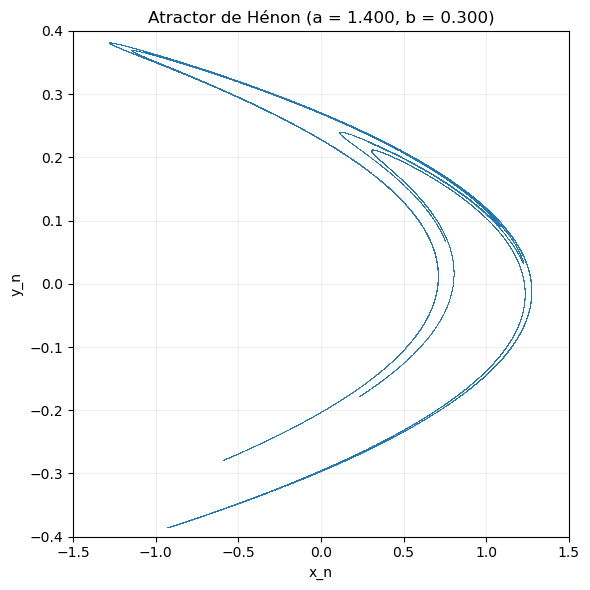

In [3]:
plot_attractor_henon(
    a=1.4,
    b=0.3,
    x0=0.0,
    y0=0.0,
    n_transient=2000,
    n_points=80_000,
    xlim=(-1.5, 1.5),
    ylim=(-0.4, 0.4),
)


#### Interpretación del atractor del mapa de Hénon en el plano de fases

La figura representa el retrato de fase del mapa de Hénon, es decir, los puntos
$(x_n, y_n)$ visitados por la órbita tras descartar las iteraciones
transitorias.

Se aprecia una estructura geométrica muy característica:

- El conjunto de puntos se concentra en una región acotada del plano $(x,y)$,
  con una forma plegada y estirada que se repite a distintas escalas.
- La distribución no llena el plano de forma uniforme, sino que se organiza en
  bandas finas y zonas de mayor densidad, lo que sugiere una estructura
  fractal.

Este atractor extraño es una de las firmas clásicas del comportamiento caótico
en sistemas bidimensionales y justifica el interés del mapa de Hénon como
núcleo caótico en el TFG.


## 3. Diagrama tipo "bifurcación" en función de $a$

Aunque el mapa de Hénon es bidimensional, podemos construir un diagrama 
análogo al de bifurcación unidimensional proyectando sobre la coordenada $x$:

1. Fijamos un valor de $b$ (por ejemplo, $b = 0.3$).
2. Recorremos un intervalo de valores de $a$ (por ejemplo, $a \in [1.0, 1.5]$).
3. Para cada $a$:
   - generamos la órbita desde $(x_0, y_0)$,
   - descartamos $n_\text{transient}$ iteraciones,
   - representamos los siguientes $n_\text{plot}$ valores de $x_n$.

El resultado es un diagrama $x_n$ frente a $a$ que muestra cómo cambia el 
comportamiento del sistema al variar el parámetro: aparición de ciclos, 
comportamiento caótico, etc.


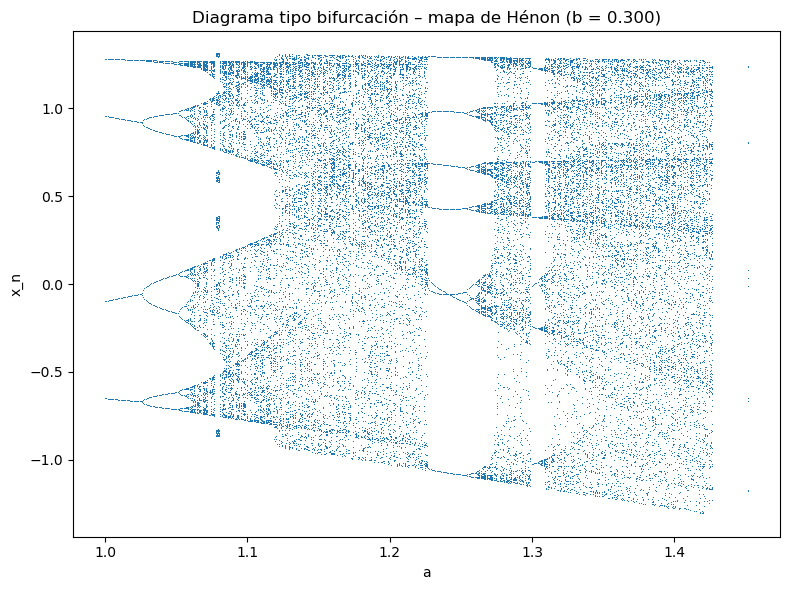

In [4]:
plot_bifurcation_henon_a(
    a_min=1.0,
    a_max=1.5,
    a_points=600,
    b=0.3,
    x0=0.0,
    y0=0.0,
    n_transient=2000,
    n_plot=80,
)


#### Interpretación del diagrama tipo bifurcación en función de $a$

El diagrama muestra, para cada valor del parámetro $a$ (con $b$ fijo), los
valores posibles de la coordenada $x_n$ en régimen estacionario.

En el gráfico se observa que:

- Para ciertos valores de $a$ los puntos se agrupan en uno o pocos niveles,
  lo que corresponde a puntos fijos o ciclos de periodo bajo.
- A medida que se modifica $a$, aparecen bifurcaciones de periodo y regiones
  donde los puntos se dispersan formando bandas densas de valores $x_n$.
- En esas regiones con muchas bandas superpuestas el comportamiento es
  claramente caótico, mientras que en otras aparecen ventanas periódicas
  incrustadas dentro del caos.

Este diagrama permite identificar los rangos de $a$ en los que el mapa de Hénon
presenta un caos suficientemente fuerte para su uso como generador
pseudoaleatorio.


## 4. Exponente de Lyapunov máximo $\lambda_1(a)$

En sistemas bidimensionales, como el mapa de Hénon, existen dos exponentes 
de Lyapunov:

- $\lambda_1$ (el mayor): mide la tasa máxima de separación exponencial entre órbitas.
- $\lambda_2$ (el menor): indica contracción en otra dirección del espacio de fases.

Para el mapa de Hénon, la jacobiana es

$$
J(x, y) =
\begin{pmatrix}
-2 a x & 1 \\
b      & 0
\end{pmatrix},
$$

y su determinante vale $\det J = -b$, constante. De aquí se deduce que

$$
\lambda_1 + \lambda_2 = \log|\det J| = \log|b|.
$$

En este notebook calculamos numéricamente el exponente máximo $\lambda_1(a)$ 
usando un método de **vector tangente**:

1. Dados $(x_n, y_n)$, se calcula la jacobiana $J(x_n, y_n)$.
2. Se propaga un vector $v_n$ mediante $v_{n+1} = J(x_n, y_n)\,v_n$.
3. Se normaliza $v_{n+1}$ y se acumula $\log \|v_{n+1}\|$.
4. El promedio de estos logaritmos aproxima $\lambda_1$.

Si $\lambda_1(a) > 0$, el sistema presenta sensibilidad a condiciones iniciales 
y, por tanto, comportamiento caótico.


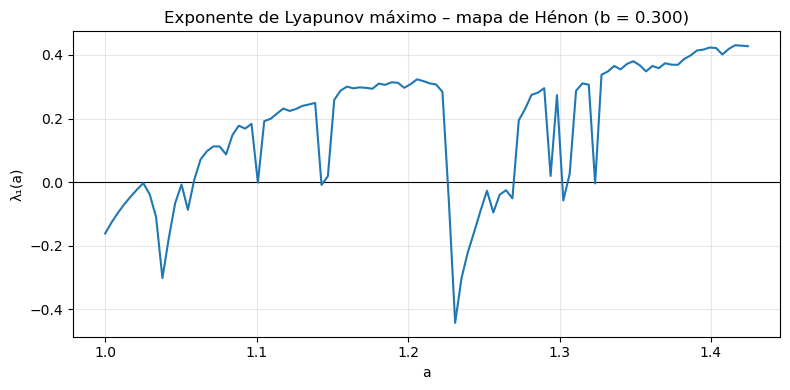

In [5]:
plot_lyapunov_vs_a_henon(
    a_min=1.0,
    a_max=1.5,
    a_points=120,
    b=b,
    x0=0.0,
    y0=0.0,
    n_transient=2000,
    n_iters=5000,
)


#### Interpretación del exponente de Lyapunov máximo $\lambda_1(a)$

La gráfica representa el exponente de Lyapunov máximo $\lambda_1(a)$ del mapa
de Hénon en función del parámetro $a$ (manteniendo $b$ fijo).

- Cuando $\lambda_1(a) < 0$, las órbitas cercanas tienden a aproximarse en el
  tiempo: el sistema es regular y acaba en puntos fijos o ciclos estables.
- Cuando $\lambda_1(a) > 0$, pequeñas diferencias en la condición inicial se
  amplifican de forma exponencial, lo que indica un régimen caótico.

Los intervalos de $a$ en los que $\lambda_1(a)$ toma valores positivos son
precisamente aquellos que nos interesan para el generador de bits, ya que
garantizan una fuerte sensibilidad a las condiciones iniciales (clave).


## 5. Efecto del número de iteraciones transitorias

Igual que en los mapas unidimensionales, para utilizar el mapa de Hénon en un 
generador de bits conviene descartar un número suficiente de iteraciones 
transitorias, de forma que la órbita se acerque al atractor y "olvide" la 
condición inicial.

Aquí se sigue el siguiente procedimiento:

1. Se genera una órbita larga $(x_n, y_n)$ de longitud $N$.
2. Para distintos valores de $T$ (0, 1000, 2000, …) se calcula la media de la 
   norma $\|(x_n, y_n)\|$ desde $n = T$ hasta el final.
3. Se representa dicha media en función de $T$.

Cuando la media se estabiliza, eso sugiere que el transitorio escogido es 
suficientemente largo para los experimentos.


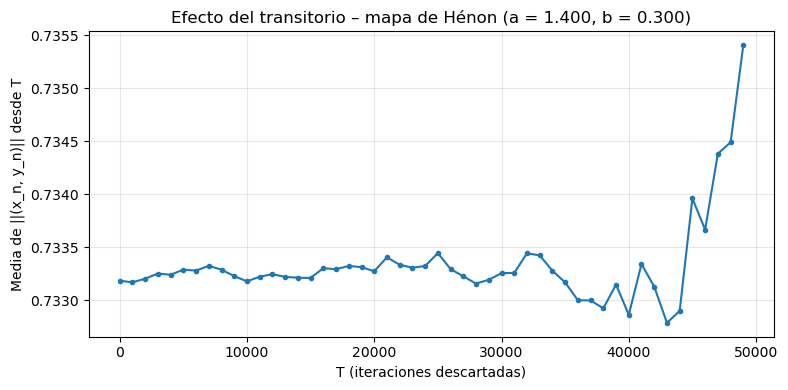

In [6]:
explore_transient_effect_henon(
    a=a,
    b=b,
    x0=0.0,
    y0=0.0,
    n_total=50_000,
    step=1000,
)


#### Interpretación del efecto del transitorio en el mapa de Hénon

La figura estudia cómo cambia la media de la norma $\lVert(x_n, y_n)\rVert$
al descartar distintos números de iteraciones transitorias $T$.

Se observa que:

- Para valores pequeños de $T$, la media de $\lVert(x_n, y_n)\rVert$ muestra
  variaciones moderadas pero se mantiene en un intervalo muy estrecho alrededor
  de un valor casi constante.
- A partir de unas cuantas decenas de miles de iteraciones descartadas la curva
  presenta una meseta clara: la media permanece prácticamente estable, lo que
  indica que las estadísticas básicas de la órbita apenas dependen ya de la
  condición inicial.
- Cuando $T$ se aproxima al número total de iteraciones, la estimación se vuelve
  más ruidosa y aparecen oscilaciones grandes. Esto se debe a que la media se
  calcula a partir de muy pocos puntos y a las propias limitaciones de precisión
  numérica.

Este comportamiento sugiere que descartar un transitorio del orden de
$20\,000$–$30\,000$ iteraciones es suficiente para que las estadísticas del
sistema (como la media de $\lVert(x_n, y_n)\rVert$) sean representativas del
atractor y prácticamente independientes de la condición inicial.


## 6. Justificación empírica del umbral de binarización

En el generador de bits basado en el mapa de Hénon, cada valor de la órbita se
transforma en un bit mediante la regla

$$
u_n = x_n - \lfloor x_n \rfloor \in [0,1), 
\qquad
\text{bit}_n =
\begin{cases}
1 & \text{si } u_n > \theta, \\
0 & \text{en otro caso},
\end{cases}
$$

donde $u_n$ es la parte fraccionaria de $x_n$ y $\theta \in (0,1)$ es el
umbral de binarización.

La idea es que, en la región caótica del mapa de Hénon, la órbita explora el
atractor de forma muy compleja y la parte fraccionaria $u_n$ puede modelarse,
de manera aproximada, como una variable aleatoria con distribución casi
uniforme en el intervalo $[0,1)$.

Si $U$ es una variable uniforme en $[0,1)$ se tiene

$$
\mathbb{P}(U > \theta) = 1 - \theta.
$$

En particular, para $\theta = 0.5$ se obtiene

$$
\mathbb{P}(U > 0.5) = 0.5,
$$

de modo que el umbral $\theta = 0.5$ es un candidato natural para obtener una
secuencia de bits con una proporción de ceros y unos aproximadamente equilibrada.


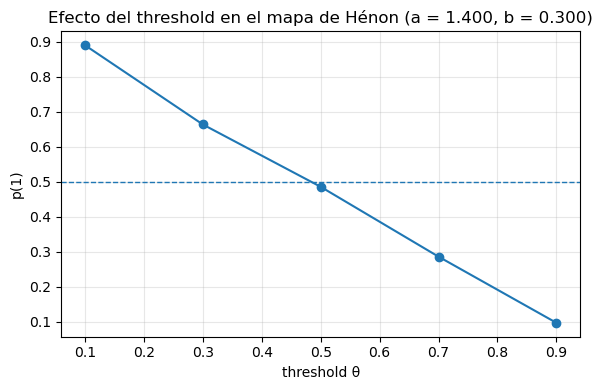

In [7]:
plot_threshold_effect_henon(
    a=1.4,
    b=0.3,
    x0=0.0,
    y0=0.0,
    n_transient=5_000,
    n_points=1_000_000,
    thresholds=[0.1, 0.3, 0.5, 0.7, 0.9],
)


#### Interpretación del efecto del threshold en el mapa de Hénon

La figura anterior representa la proporción de unos $\hat{p}(1)$ obtenida al
binarizar la parte fraccionaria de $x_n$ para distintos valores del umbral
$\theta$, manteniendo fijos los parámetros $(a, b)$ en un régimen caótico.

Se observa que:

- La proporción de unos $\hat{p}(1)$ decrece de forma aproximadamente
  monótona al aumentar el umbral $\theta$, tal y como se esperaría si la
  parte fraccionaria $u_n$ estuviera cercana a una distribución uniforme
  en $[0,1)$.
- Para $\theta = 0.5$ se obtiene un valor de $\hat{p}(1)$ muy próximo a
  $0.5$, lo que indica que la secuencia de bits resultante tiene un
  balance de ceros y unos razonablemente equilibrado.
- Para valores extremos de $\theta$ (muy pequeños o muy grandes), la
  proporción de unos se aproxima a $1$ o a $0$, respectivamente, lo cual
  confirma que el threshold controla de forma efectiva el sesgo de la
  secuencia binaria.

Este experimento empírico respalda la elección de $\theta = 0.5$ como valor
de referencia para el umbral de binarización en el generador de bits basado en
el mapa de Hénon.


## 7. Limitaciones numéricas y precisión en coma flotante

En este apartado se estudian algunos aspectos numéricos relacionados con la implementación del mapa de Hénon en coma flotante de doble precisión:

1. La resolución del formato `float64` y el número máximo de valores distintos que caben en un intervalo $(0,1)$.
2. Una estimación del tamaño del espacio de claves cuando se utilizan como parte de la clave los parámetros y condiciones iniciales reales $(a, x_0, y_0)$ acotados a regiones caóticas.
3. La aparición (inevitable) de ciclos periódicos debidos al espacio de estados finito.
4. La divergencia de órbitas con condiciones iniciales muy próximas y su relación con el exponente de Lyapunov.

El objetivo es conectar la teoría caótica con las limitaciones prácticas de la aritmética de coma flotante y del tamaño efectivo del *keyspace* en aplicaciones criptográficas basadas en el mapa de Hénon.


### 7.1 Resolución numérica y valores distintos en $(0,1)$

En el generador de bits y en el estudio del mapa de Hénon se utilizan variables reales representadas en formato de doble precisión (`float64`). Este formato no permite representar un continuo de valores, sino un conjunto discreto de números espaciados.

Para cuantificar esta resolución, se estudia la separación entre números de doble precisión alrededor de $x = 0.5$ mediante la función `float_spacing_around_05()`. A partir de esa separación $\varepsilon$ se puede estimar cuántos valores diferentes caben en el intervalo $(0,1)$ y cuántos bits de entropía binaria aportaría una variable real restringida a dicho intervalo.


In [8]:
# 7.1 Tamaño del keyspace asociado a variables reales en doble precisión

eps_info = float_spacing_around_05()

print("Resolución numérica en doble precisión alrededor de x = 0.5")
print("-" * 70)
print(f"x       = {eps_info['x']}")
print(f"x_prev  = {eps_info['x_prev']}")
print(f"x_next  = {eps_info['x_next']}")
print()
print(f"eps_minus = x - x_prev   ≈ {eps_info['eps_minus']:.3e}")
print(f"eps_plus  = x_next - x   ≈ {eps_info['eps_plus']:.3e}")
print()
print(f"N_vals  ≈ {eps_info['n_vals_interval']:.3e} valores distintos en el intervalo (0,1)")
print(f"Bits    ≈ {eps_info['log2_n_vals_interval']:.2f} bits de entropía binaria")


Resolución numérica en doble precisión alrededor de x = 0.5
----------------------------------------------------------------------
x       = 0.5
x_prev  = 0.49999999999999994
x_next  = 0.5000000000000001

eps_minus = x - x_prev   ≈ 5.551e-17
eps_plus  = x_next - x   ≈ 1.110e-16

N_vals  ≈ 9.007e+15 valores distintos en el intervalo (0,1)
Bits    ≈ 53.00 bits de entropía binaria


La salida numérica muestra que:

* La separación entre números de doble precisión alrededor de $x = 0.5$ es del orden de $2^{-52} \approx 2.2\cdot 10^{-16}$.
* En consecuencia, el intervalo $(0,1)$ contiene como máximo del orden de $N \approx 2^{52} \approx 4.5\cdot 10^{15}$ valores distintos representables.
* Esto equivale a unos $52$ bits de entropía binaria para una variable real acotada en $(0,1)$ cuando se representa en `float64`.

Este orden de magnitud será la base para estimar el tamaño del espacio de claves asociado a los parámetros y condiciones iniciales del mapa de Hénon.


### 7.2 Estimación del espacio de claves basado en $(a, x_0, y_0)$

Supongamos que en un esquema criptográfico se utilizan como parte de la clave:

* el parámetro $a$ restringido a un intervalo caótico, por ejemplo $a \in [1.2, 1.5]$,
* las coordenadas de la condición inicial $(x_0, y_0)$ restringidas a un rectángulo que cubre el atractor, por ejemplo $x_0, y_0 \in [-1.5, 1.5]$.

Si cada una de estas variables se representa en doble precisión, el número aproximado de valores distintos que puede tomar viene dado por la capacidad del intervalo correspondiente. Usando `interval_capacity(L)` y `bits_from_interval(L)` podemos estimar tanto el número de valores posibles como los bits de entropía aportados por cada componente de la clave.


In [9]:
# 7.2 Estimación del espacio de claves basado en (a, x0, y0)

# Longitudes de los intervalos que consideramos
L_a  = 1.5 - 1.2        # a ∈ [1.2, 1.5]
L_x0 = 3.0              # x0 ∈ [-1.5, 1.5]
L_y0 = 3.0              # y0 ∈ [-1.5, 1.5]

info_a  = interval_capacity(L_a)
info_x0 = interval_capacity(L_x0)
info_y0 = interval_capacity(L_y0)

N_a  = info_a["N_vals"]
N_x0 = info_x0["N_vals"]
N_y0 = info_y0["N_vals"]

bits_a  = info_a["log2_N_vals"]
bits_x0 = info_x0["log2_N_vals"]
bits_y0 = info_y0["log2_N_vals"]

total_bits = bits_a + bits_x0 + bits_y0

print("Mapa de Hénon – estimación del espacio de claves basado en (a, x0, y0)")
print("-" * 72)
print()
print("Intervalo para a  : [1.2, 1.5]")
print(f"  L_a = {L_a}")
print(f"  Valores distintos aproximados de a   ~ {N_a:.3e}")
print(f"  Bits de entropía aportados por a     ~ {bits_a:.2f} bits")
print()
print("Intervalo para x0 : [-1.5, 1.5]")
print(f"  L_x0 = {L_x0}")
print(f"  Valores distintos aproximados de x0  ~ {N_x0:.3e}")
print(f"  Bits de entropía aportados por x0    ~ {bits_x0:.2f} bits")
print()
print("Intervalo para y0 : [-1.5, 1.5]")
print(f"  L_y0 = {L_y0}")
print(f"  Valores distintos aproximados de y0  ~ {N_y0:.3e}")
print(f"  Bits de entropía aportados por y0    ~ {bits_y0:.2f} bits")
print()
print(f"Bits de entropía combinados (a, x0, y0)  ~ {total_bits:.2f} bits")
print(f"Equivalente a un espacio de claves del orden de 2^{total_bits:.1f}")


Mapa de Hénon – estimación del espacio de claves basado en (a, x0, y0)
------------------------------------------------------------------------

Intervalo para a  : [1.2, 1.5]
  L_a = 0.30000000000000004
  Valores distintos aproximados de a   ~ 2.702e+15
  Bits de entropía aportados por a     ~ 51.26 bits

Intervalo para x0 : [-1.5, 1.5]
  L_x0 = 3.0
  Valores distintos aproximados de x0  ~ 2.702e+16
  Bits de entropía aportados por x0    ~ 54.58 bits

Intervalo para y0 : [-1.5, 1.5]
  L_y0 = 3.0
  Valores distintos aproximados de y0  ~ 2.702e+16
  Bits de entropía aportados por y0    ~ 54.58 bits

Bits de entropía combinados (a, x0, y0)  ~ 160.43 bits
Equivalente a un espacio de claves del orden de 2^160.4


En la salida se observa que, aproximadamente:

* El parámetro $a$ en $[1.2, 1.5]$ aporta del orden de $N_a$ valores distintos y unos $b_a \approx 50$ bits de entropía.
* Cada coordenada de la condición inicial $x_0$ y $y_0$, restringidas a $[-1.5, 1.5]$, aporta también del orden de $N_{x_0}$ y $N_{y_0}$ valores distintos, con unos $b_{x_0} \approx b_{y_0} \approx 53$ bits de entropía por coordenada.

En conjunto, la terna $(a, x_0, y_0)$ ofrece un espacio de claves efectivo del orden de
$2^{B}$ estados posibles, donde $B$ es la suma de los bits aportados por cada variable (en este ejemplo, del orden de más de $150$ bits de entropía).

Esta estimación es una **cota superior teórica** basada únicamente en la resolución de los números `float64` y en la longitud de los intervalos considerados. En la práctica el espacio de claves efectivo puede ser algo menor porque:

* no todos los valores de $(a, x_0, y_0)$ producen órbitas caóticas útiles,
* algunas combinaciones pueden conducir a divergencia numérica o a ciclos de periodo pequeño,
* y el esquema de cifrado concreto puede introducir restricciones adicionales sobre los parámetros.

Aun así, la estimación indica que, desde el punto de vista puramente numérico, el mapa de Hénon dispone de un espacio de claves muy amplio cuando se usan parámetros y condiciones iniciales en doble precisión dentro de regiones caóticas.


### 7.3 Búsqueda de ciclos en una órbita larga

Debido a que la aritmética de doble precisión sólo permite un número finito de estados, toda órbita del mapa de Hénon acaba siendo periódica: en algún momento se repite un par $(x_n, y_n)$ y, a partir de ahí, la dinámica entra en un ciclo.

Para ilustrar este fenómeno, se genera una órbita larga y se utiliza la función `detect_cycle_henon(...)` para buscar, después de descartar un transitorio, si aparece un ciclo de periodo pequeño dentro de una tolerancia numérica dada.


In [10]:
# 7.3 Búsqueda aproximada de ciclos en una órbita del mapa de Hénon

a_c = 1.4
b_c = 0.3
x0_c = 0.0
y0_c = 0.0

period, idx_ref = detect_cycle_henon(
    x0=x0_c,
    y0=y0_c,
    a=a_c,
    b=b_c,
    n_total=100_000,
    n_transient=10_000,
    max_period=10_000,
    tol=1e-12,
)

print(f"Parámetros: a = {a_c}, b = {b_c}, x0 = {x0_c}, y0 = {y0_c}")
if period is None:
    print("No se ha detectado ningún ciclo de periodo ≤ 10 000 dentro de la precisión numérica.")
else:
    print(f"Se ha detectado un ciclo de periodo k = {period},")
    print(f"con punto de referencia en el índice global n = {idx_ref}.")


Parámetros: a = 1.4, b = 0.3, x0 = 0.0, y0 = 0.0
No se ha detectado ningún ciclo de periodo ≤ 10 000 dentro de la precisión numérica.


En los parámetros caóticos clásicos $(a = 1.4, b = 0.3)$ suele ocurrir que:

* No se detectan ciclos de periodo pequeño dentro del límite buscado (por ejemplo $k \leq 10\,000$), lo que es consistente con una dinámica compleja.
* Sin embargo, desde el punto de vista teórico y numérico sabemos que, al trabajar en un espacio de estados finito, la órbita debe acabar entrando en algún ciclo de periodo finito, posiblemente muy largo.

Este experimento ilustra cómo la finitud de la representación numérica introduce, de forma inevitable, periodicidad en sistemas caóticos discretizados.


### 7.4 Divergencia de órbitas con condiciones iniciales próximas

Una característica clave del comportamiento caótico es la sensibilidad extrema a las condiciones iniciales: dos órbitas que parten de puntos muy cercanos se separan exponencialmente con el tiempo.

La función `plot_divergence_two_orbits_henon(...)` representa la distancia
$\lVert \Delta(x_n, y_n) \rVert$ entre dos órbitas que difieren inicialmente en una cantidad muy pequeña $\delta_0$ en la coordenada $x_0$, usando escala semilogarítmica para resaltar la fase de crecimiento exponencial.


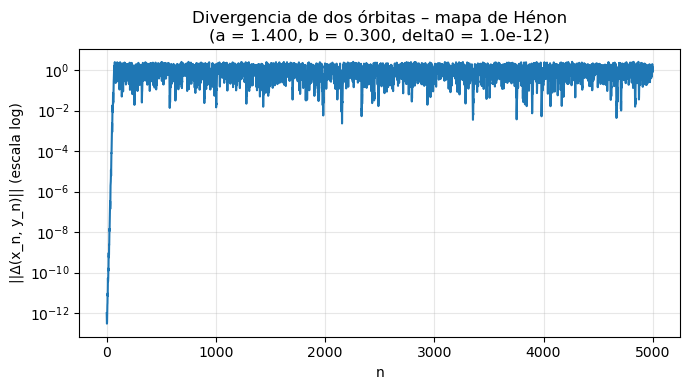

In [11]:
# 7.4 Divergencia de dos órbitas con condiciones iniciales próximas

plot_divergence_two_orbits_henon(
    a=1.4,
    b=0.3,
    x0=0.0,
    y0=0.0,
    delta0=1e-12,
    n_iters=5_000,
    log_scale=True,
)


En la gráfica se observa que:

* Al principio la distancia entre órbitas crece de forma aproximadamente exponencial, lo que se manifiesta como un tramo casi lineal en la escala semilogarítmica. La pendiente de ese tramo está relacionada con el exponente de Lyapunov máximo $\lambda_1(a)$.
* Tras cierto tiempo, la distancia se satura porque ambas órbitas están confinadas en el atractor y porque la precisión finita impide distancias arbitrariamente pequeñas.

Esta divergencia rápida de órbitas cercanas es la manifestación numérica de la sensibilidad a las condiciones iniciales en el mapa de Hénon y refuerza la interpretación de $\lambda_1(a) > 0$ como indicador de caos.


## 8. Conclusiones del análisis del mapa de Hénon

A partir de los resultados obtenidos en este notebook se pueden extraer varias ideas:

- El mapa de Hénon es un ejemplo clásico de sistema bidimensional discreto que, para los parámetros “clásicos” $(a = 1.4,\, b = 0.3)$, presenta un atractor extraño bien definido y una dinámica claramente caótica.

- La serie temporal de $x_n$ y el retrato de fase $(x_n,y_n)$ muestran que la órbita:
  - no converge a un punto fijo ni a un ciclo de periodo corto,
  - explora de forma compleja una región acotada del plano $(x,y)$,
  lo que es consistente con la presencia de un atractor caótico.

- El diagrama tipo bifurcación al variar el parámetro $a$ (con $b$ fijo) evidencia:
  - la aparición de ventanas de periodicidad y su desdoblamiento sucesivo,
  - la coexistencia de regiones periódicas y regiones caóticas,
  de forma análoga a lo observado en el mapa logístico, pero en un sistema de dimensión superior.

- El exponente de Lyapunov máximo $\lambda_1(a)$ confirma cuantitativamente estas observaciones:
  - en las zonas donde el diagrama muestra ciclos periódicos predominan valores $\lambda_1(a) < 0$,
  - en los intervalos caóticos se obtienen valores $\lambda_1(a) > 0$, indicando sensibilidad extrema a las condiciones iniciales.

- El estudio del transitorio sugiere que, para aproximar bien el atractor numérico, es razonable descartar del orden de $10^4$–$10^5$ iteraciones antes de utilizar los puntos de la órbita en cálculos estadísticos o en la generación de bits.

- La justificación empírica del umbral de binarización basada en la parte fraccionaria de $x_n$ muestra que:
  - transformar $x_n$ en $u_n = x_n - \lfloor x_n \rfloor \in [0,1)$ homogeniza la distribución,
  - umbrales en torno a $\theta = 0.5$ producen secuencias de bits con un balance de ceros y unos razonablemente cercano a $p(1) \approx 0.5$.

- Desde el punto de vista numérico, la aritmética de doble precisión impone un espacio de estados finito:
  - la resolución alrededor de $x = 0.5$ es del orden de $2^{-52}$, lo que implica unos $2^{52}$ valores distintos posibles en $(0,1)$ (unos $52$ bits de entropía por variable real acotada),
  - al combinar parámetros $(a, x_0, y_0)$ en intervalos caóticos se obtiene un espacio de claves teórico del orden de más de $150$ bits de entropía,
  aunque el espacio efectivo puede ser menor por la existencia de órbitas no caóticas o divergentes.

- La búsqueda de ciclos en órbitas largas y la representación de la divergencia de dos órbitas próximas ilustran dos efectos complementarios:
  - por un lado, la inevitabilidad de ciclos periódicos en un espacio de estados finito,
  - por otro, la separación exponencial de órbitas cercanas típica de sistemas caóticos, claramente visible en la escala semilogarítmica.

En conjunto, el análisis realizado respalda el uso del mapa de Hénon como núcleo caótico para generadores de bits pseudoaleatorios y esquemas criptográficos, siempre que se elijan adecuadamente las regiones de parámetros caóticos, los transitorios y las transformaciones numéricas (binarización, normalización, etc.) para mitigar las limitaciones de la aritmética de coma flotante.


## Anexo A – Sensibilidad al parámetro del mapa de Hénon

En las secciones anteriores se ha estudiado la sensibilidad del mapa de Hénon a las
**condiciones iniciales** (divergencia de órbitas próximas) y se ha calculado el
exponente de Lyapunov máximo $\lambda_1(a)$.

En este anexo se ilustra de forma cualitativa la **sensibilidad a cambios en el
parámetro** $a$:

- Se fija un valor de referencia $a$ en la región caótica (por ejemplo $a = 1.4$,
  $b = 0.3$).
- Se consideran dos sistemas con el mismo estado inicial $(x_0, y_0)$:
  - Sistema 1: parámetros $(a, b)$.
  - Sistema 2: parámetros $(a + \Delta a, b)$, donde $\Delta a$ es una perturbación
    muy pequeña (por ejemplo $\Delta a = 10^{-6}$).
- Se genera la órbita de ambos sistemas durante un número de iteraciones $n$ y se
  mide la distancia
  $$
    d_n = \big\|(x_n^{(a)}, y_n^{(a)}) - (x_n^{(a+\Delta a)}, y_n^{(a+\Delta a)})\big\|.
  $$
- Finalmente, se representa $d_n$ en función de $n$, normalmente en escala
  semilogarítmica para resaltar las fases de crecimiento casi exponencial.


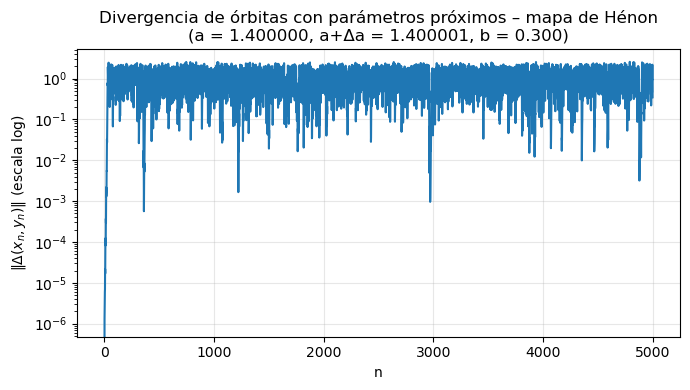

In [12]:
# Parámetros en la zona caótica
a_ref = 1.4
delta_a = 1e-6    # pequeña variación en el parámetro a
b = 0.3
x0 = 0.0
y0 = 0.0

plot_divergence_two_params_henon(
    a=a_ref,
    delta_a=delta_a,
    b=b,
    x0=x0,
    y0=y0,
    n_iters=5_000,
    log_scale=True,
)


### Interpretación del experimento de sensibilidad al parámetro

En la gráfica anterior se representa la distancia $d_n$ entre dos órbitas que:

- comparten la misma condición inicial $(x_0, y_0)$,
- pero evolucionan con parámetros ligeramente distintos $(a, b)$ y $(a + \Delta a, b)$.

Se observa típicamente que:

- Para los primeros iterados, la diferencia entre ambas órbitas es muy pequeña
  (del orden de la perturbación inicial en el parámetro).
- A partir de cierto momento, la distancia $d_n$ empieza a crecer de forma
  rápida y, en escala semilogarítmica, se aprecia una fase con crecimiento
  casi lineal en $\log d_n$, indicativa de un comportamiento cercano al
  crecimiento exponencial.
- Después de esa fase, la distancia se satura en un valor comparable al tamaño
  de la región del atractor, ya que ambas órbitas exploran zonas distintas
  del espacio de fases.

Este experimento ilustra que, en la región caótica, el mapa de Hénon no solo es
extremadamente sensible a las **condiciones iniciales**, sino también a pequeñas
variaciones en el **parámetro** $a$. Desde el punto de vista criptográfico, esto
refuerza la idea de que diferentes elecciones de parámetros dentro de la región
caótica pueden generar órbitas y secuencias de bits muy distintas incluso cuando
se parte del mismo estado inicial.
